In [7]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [8]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

In [4]:
train_df = pd.read_csv('data_train.csv', sep="\t")
test_df = pd.read_csv('data_test.csv', sep="\t")

### Rodando com 500 primeiros datapoints

In [5]:
n_init_points = 500
short_train_df = train_df.iloc[:,:n_init_points].copy()
short_train_df['y'] = train_df['y']
short_test_df = test_df.iloc[:,:n_init_points].copy()
# short_train_df

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [95]:
n_init_points = 500
X = torch.Tensor(np.array(short_train_df.iloc[:,:n_init_points]))
y = torch.Tensor(np.array(short_train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [115]:
model = nn.Sequential(
    nn.Linear(n_init_points,256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.060042 | Val MSE: 0.044452
Epoch 10 | Train MSE: 0.016968 | Val MSE: 0.018775
Epoch 20 | Train MSE: 0.011809 | Val MSE: 0.011613
Epoch 30 | Train MSE: 0.009173 | Val MSE: 0.011520
Epoch 40 | Train MSE: 0.007505 | Val MSE: 0.010423
Epoch 50 | Train MSE: 0.006547 | Val MSE: 0.011114
Epoch 60 | Train MSE: 0.006492 | Val MSE: 0.011226
Epoch 70 | Train MSE: 0.007521 | Val MSE: 0.012540


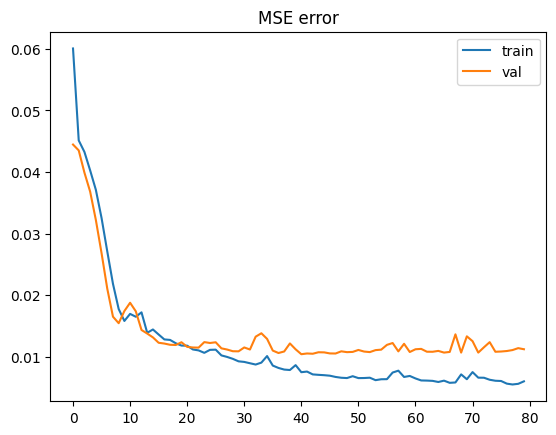

In [116]:
epochs = 80  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

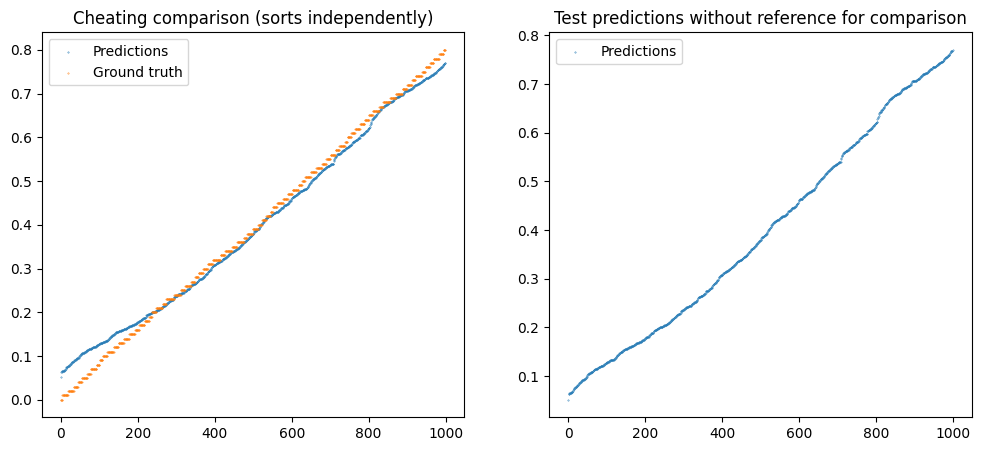

In [138]:
#evaluate
model.eval()
with torch.no_grad():
    sampled_idx = range(1000)#np.random.randint(1,1000,10)
    x_new = X[sampled_idx]
    y_pred = model(x_new)

#evaluate
Xtest = torch.Tensor(np.array(short_test_df.iloc[:,:500]))
model.eval()
with torch.no_grad():
    y_pred = model(Xtest)

fig,ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(range(1000),sorted(y_pred), s=.1, label="Predictions")
ax[0].scatter(range(1000),sorted(y), s=.1, label="Ground truth")
ax[0].set_title("Cheating comparison (sorts independently)")
ax[0].legend()

ax[1].scatter(range(1000),sorted(y_pred), s=.1, label="Predictions")
ax[1].legend()
ax[1].set_title('Test predictions without reference for comparison')
plt.show()

In [209]:
write_csv_file(y_pred.squeeze().detach().cpu().numpy())

,CPMG,%
0,CPMG_000.csv,0.386244
1,CPMG_001.csv,0.694590
2,CPMG_002.csv,0.217418
3,CPMG_003.csv,0.326525
4,CPMG_004.csv,0.102075
...,...,...
995,CPMG_995.csv,0.217330
996,CPMG_996.csv,0.735972
997,CPMG_997.csv,0.179982
998,CPMG_998.csv,0.328672


### Fazendo PCA

In [198]:
train_df = pd.read_csv('data_train.csv', sep="\t")
test_df = pd.read_csv('data_test.csv', sep="\t")

In [199]:
pca = sklearn.decomposition.PCA(n_components=.95)
pca.fit(train_df.T[:-1].T)

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [211]:
new_train_df = pd.DataFrame(pca.transform(train_df.iloc[:,:-1]))
new_train_df['y'] = train_df['y']
new_test_df = pd.DataFrame(pca.transform(test_df))
new_train_df.to_csv("data_train_PCA.csv", sep="\t")
new_test_df.to_csv("data_test_PCA.csv", sep="\t")

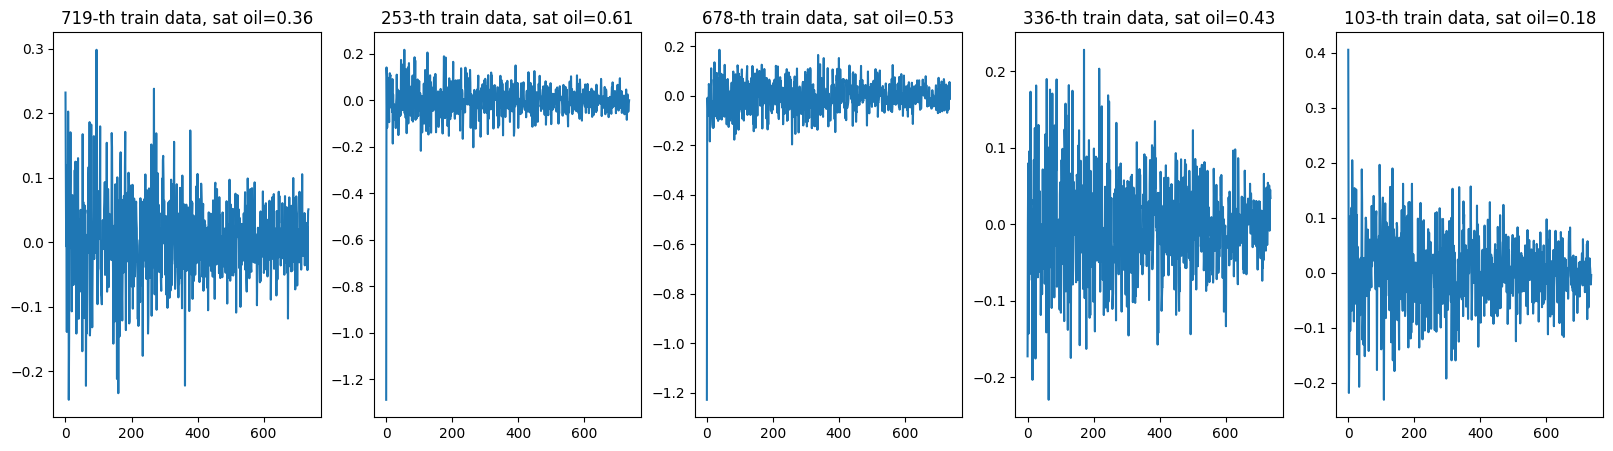

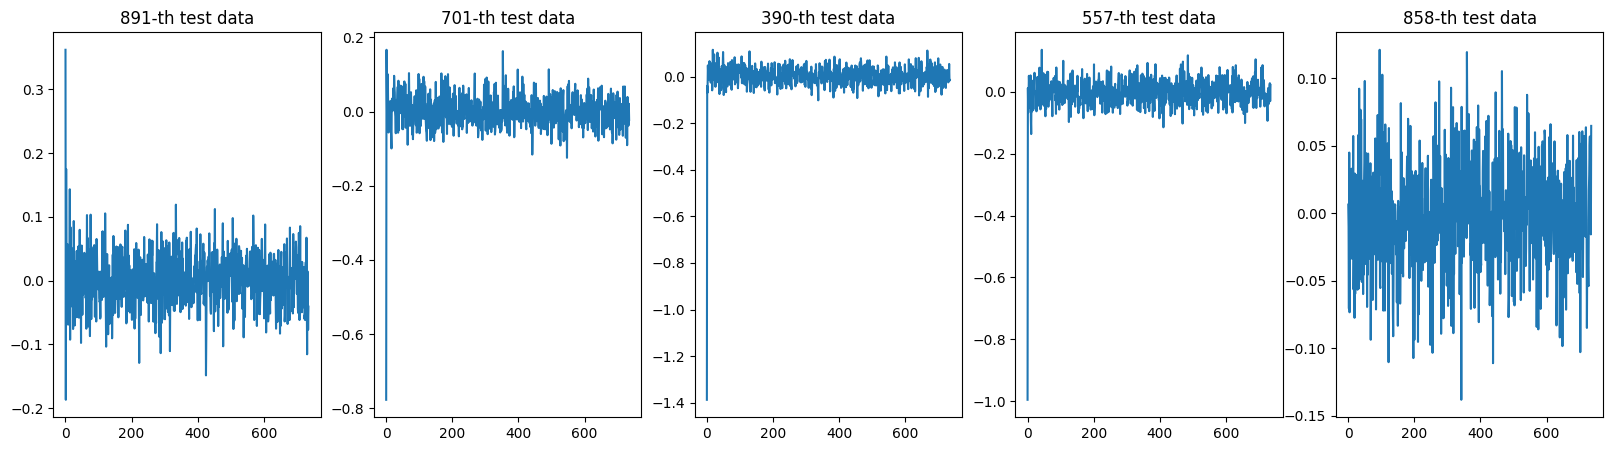

In [212]:
'''Plot graph of test and train after PCA'''
fig, ax = plt.subplots(1,5, figsize=(20,5))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(new_train_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data, sat oil={new_train_df.iloc[j,-1]}")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,5))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(new_test_df.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th test data")
plt.show();

Arquivos .csv pós-PCA gerados.<br>
Márcio: não sei interpretar bem esse PCA. Rodando a mesma rede, resultado similares a tomar os primeiros 500 pontos

In [213]:
X = torch.Tensor(np.array(new_train_df))
y = torch.Tensor(np.array(new_train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [214]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.062797 | Val MSE: 0.050186
Epoch 10 | Train MSE: 0.003955 | Val MSE: 0.011434
Epoch 20 | Train MSE: 0.000566 | Val MSE: 0.010644
Epoch 30 | Train MSE: 0.000146 | Val MSE: 0.010750


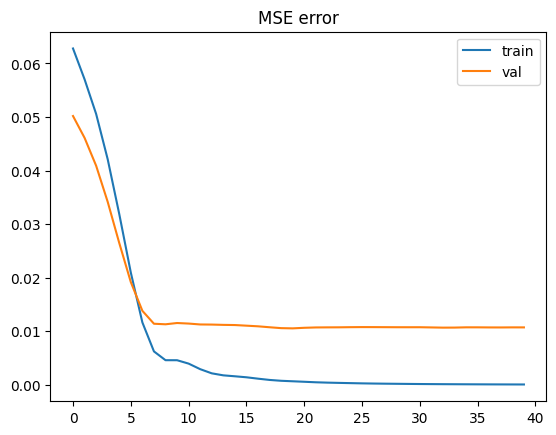

In [215]:
epochs = 40
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Agora com CatBoost

In [139]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.3 MB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 98.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


## Catboost: training setup

In [301]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

n_init_points = 500
X = np.array(train_df.iloc[:,:n_init_points])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


RMSE: 0.09161282826511344 MAE: 0.07161231120027364


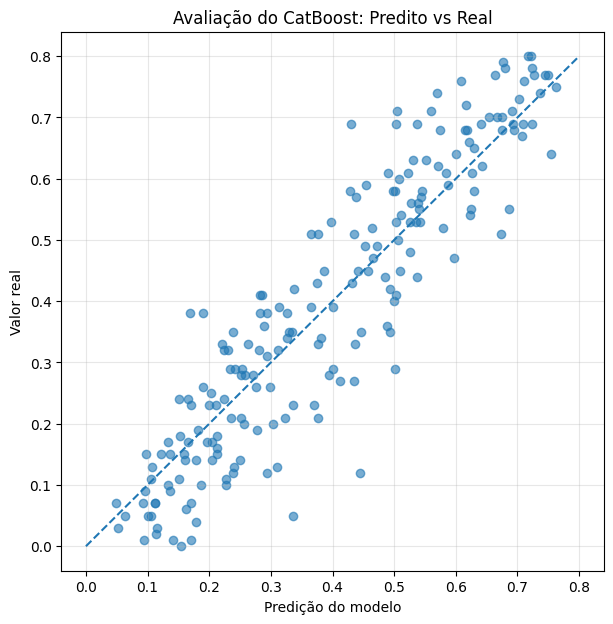

In [302]:
y_pred = model.predict(Xval)

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred - yval)**2))
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [196]:
Xtest = np.array(short_test_df.iloc[:,:n_init_points])
write_csv_file(model.predict(Xtest))

,CPMG,%
0,CPMG_000.csv,0.274665
1,CPMG_001.csv,0.669553
2,CPMG_002.csv,0.183837
3,CPMG_003.csv,0.434456
4,CPMG_004.csv,0.072703
...,...,...
995,CPMG_995.csv,0.242696
996,CPMG_996.csv,0.748017
997,CPMG_997.csv,0.209394
998,CPMG_998.csv,0.225531


## Agora uma CNN, por favor

In [10]:
train_df = pd.read_csv('data_train_norm.csv', sep="\t")
test_df = pd.read_csv('data_test_norm.csv', sep="\t")

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(1).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [18]:
model = nn.Sequential(
    nn.Conv1d(1,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(4,16,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(16,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),
    
    nn.Flatten(),
    nn.Linear(132,64),
    nn.ReLU(),

    nn.Linear(64,16),
    nn.ReLU(),
        
    nn.Linear(16,1),
    nn.Sigmoid()
).to(device)

#to get the size right in the linear layer
# x = torch.randn(1000, 1, 2201)
# out = model(x)
# print(out.shape)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 04 | Train MSE: 0.010491 | Val MSE: 0.010895
Epoch 09 | Train MSE: 0.010508 | Val MSE: 0.010869
Epoch 14 | Train MSE: 0.010335 | Val MSE: 0.010770
Epoch 19 | Train MSE: 0.010279 | Val MSE: 0.010563
Epoch 24 | Train MSE: 0.010166 | Val MSE: 0.010517
Epoch 29 | Train MSE: 0.010604 | Val MSE: 0.010512
Epoch 34 | Train MSE: 0.010023 | Val MSE: 0.010375
Epoch 39 | Train MSE: 0.010021 | Val MSE: 0.010403
Epoch 44 | Train MSE: 0.010253 | Val MSE: 0.010797
Epoch 49 | Train MSE: 0.010418 | Val MSE: 0.010875
Epoch 54 | Train MSE: 0.009830 | Val MSE: 0.010111
Epoch 59 | Train MSE: 0.009893 | Val MSE: 0.010624
Epoch 64 | Train MSE: 0.009622 | Val MSE: 0.010064
Epoch 69 | Train MSE: 0.010605 | Val MSE: 0.010677
Epoch 74 | Train MSE: 0.010418 | Val MSE: 0.010293
Epoch 79 | Train MSE: 0.009513 | Val MSE: 0.009823
Epoch 84 | Train MSE: 0.009463 | Val MSE: 0.010167
Epoch 89 | Train MSE: 0.009362 | Val MSE: 0.009702
Epoch 94 | Train MSE: 0.010483 | Val MSE: 0.011428
Epoch 99 | Train MSE: 0.011874 

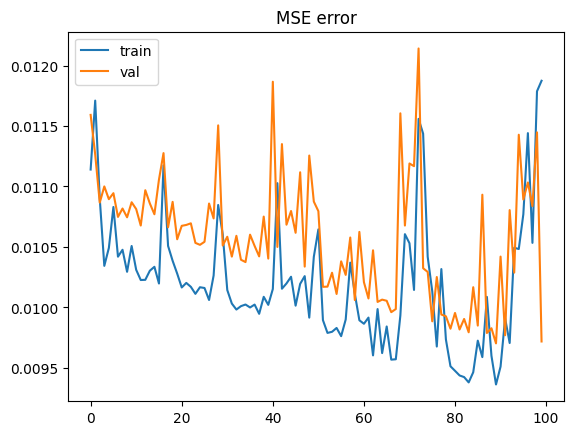

In [21]:
epochs = 100
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch+1)%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.098578595 R²: 0.79303676 MAE: 0.07919805


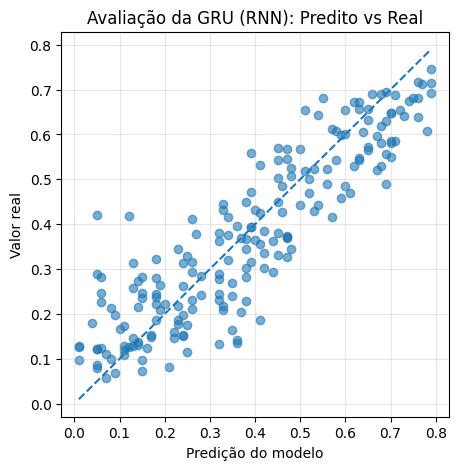

In [22]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1 - mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

## RNN: GRU

In [395]:
train_df = pd.read_csv('data_train.csv', sep="\t")
test_df = pd.read_csv('data_test.csv', sep="\t")

In [396]:
X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(2)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
X.shape

torch.Size([1000, 2201, 1])

In [400]:
hidden_size = 16
gru = nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True)
head = nn.Linear(hidden_size, 1)   # prediction head

# combine params from both "submodules"
optimizer = torch.optim.Adam(list(gru.parameters()) + list(head.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epoch 01 | train MSE: 0.061961
epoch 02 | train MSE: 0.059212
epoch 03 | train MSE: 0.057088
epoch 04 | train MSE: 0.055317
epoch 05 | train MSE: 0.054162
epoch 06 | train MSE: 0.053499
epoch 07 | train MSE: 0.053155
epoch 08 | train MSE: 0.053113
epoch 09 | train MSE: 0.053090
epoch 10 | train MSE: 0.053093


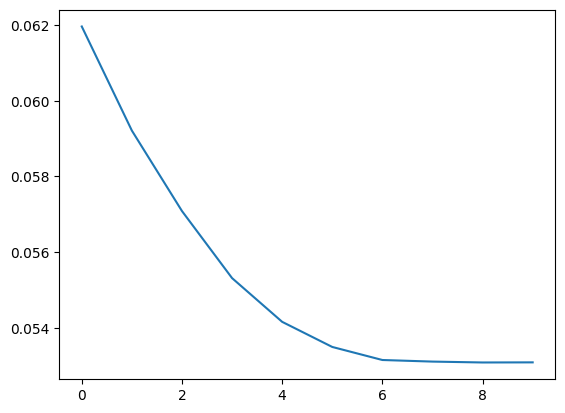

In [401]:
# ----- training loop -----
gru.train(); head.train()
loss_history = []
for epoch in range(10):
    train_loss = 0.0
    for xb, yb in train_loader:
        # forward (manual “forward”)
        out, h = gru(xb)               # out: (B, T, H), h: (1, B, H)
        feat = out[:, -1, :]           # OR: h[-1]  (both are (B, H))
        pred = torch.sigmoid(head(feat))  # keep in [0,1]

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    loss_history.append(train_loss/len(train_loader.dataset))
    print(f"epoch {epoch+1:02d} | train MSE: {train_loss/len(train_loader.dataset):.6f}")
plt.plot(loss_history);

RMSE: 0.23113929010703144 MAE: 0.20313882625102997


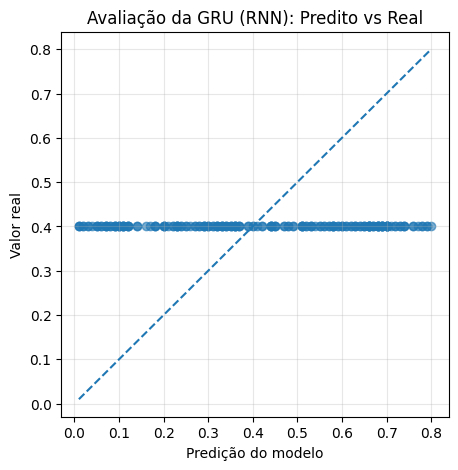

In [402]:
# ----- inference -----
gru.eval(); head.eval()
val_loss = 0
with torch.no_grad():
    for xb, yb in val_loader:
        out, h = gru(xb)
        feat = out[:, -1, :]
        y_pred = torch.sigmoid(head(feat))
        val_loss += criterion(y_pred, yb).item() * xb.size(0)
val_loss /= len(val_loader.dataset)

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))**2))
mae = np.mean(np.abs((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Horrível, algo deu errado aqui

## Random Forest

In [388]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:500])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


In [391]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.11414678488682894 MAE: 0.088831


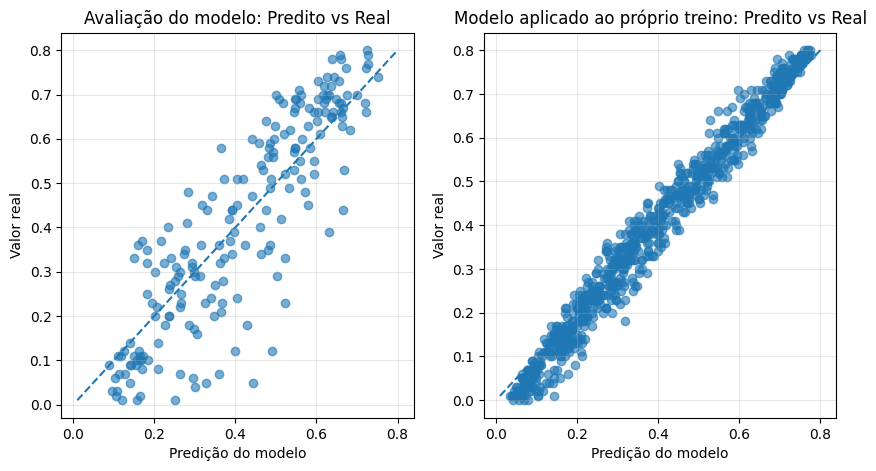

In [392]:
rmse = np.sqrt(np.mean((y_pred - yval)**2))
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
fig, (ax0,ax1) = plt.subplots(1,2, figsize=(10, 5))
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

ax0.scatter(y_pred, yval, alpha=0.6)
ax0.plot([min_val, max_val], [min_val, max_val], '--')
ax0.set_xlabel("Predição do modelo")
ax0.set_ylabel("Valor real")
ax0.set_title("Avaliação do modelo: Predito vs Real")
ax0.grid(True, alpha=0.3)

ax1.scatter(y_tr_pred, ytrain, alpha=0.6)
ax1.plot([min_val, max_val], [min_val, max_val], '--')
ax1.set_xlabel("Predição do modelo")
ax1.set_ylabel("Valor real")
ax1.set_title("Modelo aplicado ao próprio treino: Predito vs Real")
ax1.grid(True, alpha=0.3)

plt.show()

Resultado fraco